# Searching for a Needle in a "Signal Haystack"

In [1]:
from pathlib import Path
import sys

COURSEUTILS_DIR = Path.home() / "Documents/GitHub/Signals_and_Systems/courseutils"
sys.path.insert(0, str(COURSEUTILS_DIR))

In [2]:
import basic_material as bm
if hasattr(bm, "setup_environment"):
    bm.setup_environment()

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Audio/recording dependencies used by later cells
import os
from scipy.io.wavfile import write
import IPython.display as ipd
from ipywidgets import interactive

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

In [4]:
# store data
def store_data(signal,stack):
    # sum will treat Boolean True as a 1, False as a 0
    n = sum(os.path.isfile("data/"+name) for name in os.listdir('data/'))
    file_name = "data/Store_%s" % n 
    print("\nStoring recorded data in",file_name)

    np.savetxt(file_name+"_signal.csv", signal, delimiter=",")
    np.savetxt(file_name+"_stack.csv", stack, delimiter=",")

    signal_read = np.loadtxt(file_name+"_signal.csv",delimiter=',',skiprows=0)  
    stack_read = np.loadtxt(file_name+"_stack.csv",delimiter=',',skiprows=0)  

    print(f"Signal reload errors of {np.max(np.abs(signal_read - signal)):.6e}")
    print(f"Stack reload errors of {np.max(np.abs(stack_read - stack)):.6e}\n")
    
    return file_name

## Discussion:
* Consider case of a received signal that is weak (low amplitude) and there is lots of noise.

* All we know is that it is a sinusoidal signal and we have rough idea of the signal frequency

In [5]:
dt = 0.001 # emulate measuring a cts signal by having dt very small compared to freq of signal
tf = 60 # sec of data
t = np.arange(0,tf,dt)

In [6]:
# Truth variables (i.e. not known to us)
omega_lower_bound = 10
omega_upper_bound = 20

try:
    from hidden_omega0 import get_truth
    seed = 50
    omega0, f0, T0, phi_true = get_truth(omega_lower_bound, omega_upper_bound, seed = seed)
except ModuleNotFoundError:
    print(
        f"hidden_omega0.py not found on sys.path. Expected at: {COURSEUTILS_DIR / 'hidden_omega0.py'}"
    )
    print("Using deterministic fallback truth generator.")
    seed = 100
    rng = np.random.default_rng(seed)
    omega0 = float(rng.uniform(omega_lower_bound, omega_upper_bound))
    f0 = omega0 / (2 * np.pi)
    T0 = 1 / f0
    phi_true = float(rng.uniform(0, 2 * np.pi))

# Actual/truth
y_true = np.sin(omega0 * t + phi_true)

# Measured
noise_seed = 200 # make results reproducible
rng_noise = np.random.default_rng(noise_seed)
y = y_true + 5 * rng_noise.normal(size=np.size(t))

In [7]:
# Guess what the signal looks like by using the bounds on omega and the max of y
omega = (omega_lower_bound + omega_upper_bound)/2
test_amplitude = 0.25*np.max(np.abs(y))
y_guess = test_amplitude*np.sin(omega * t) 

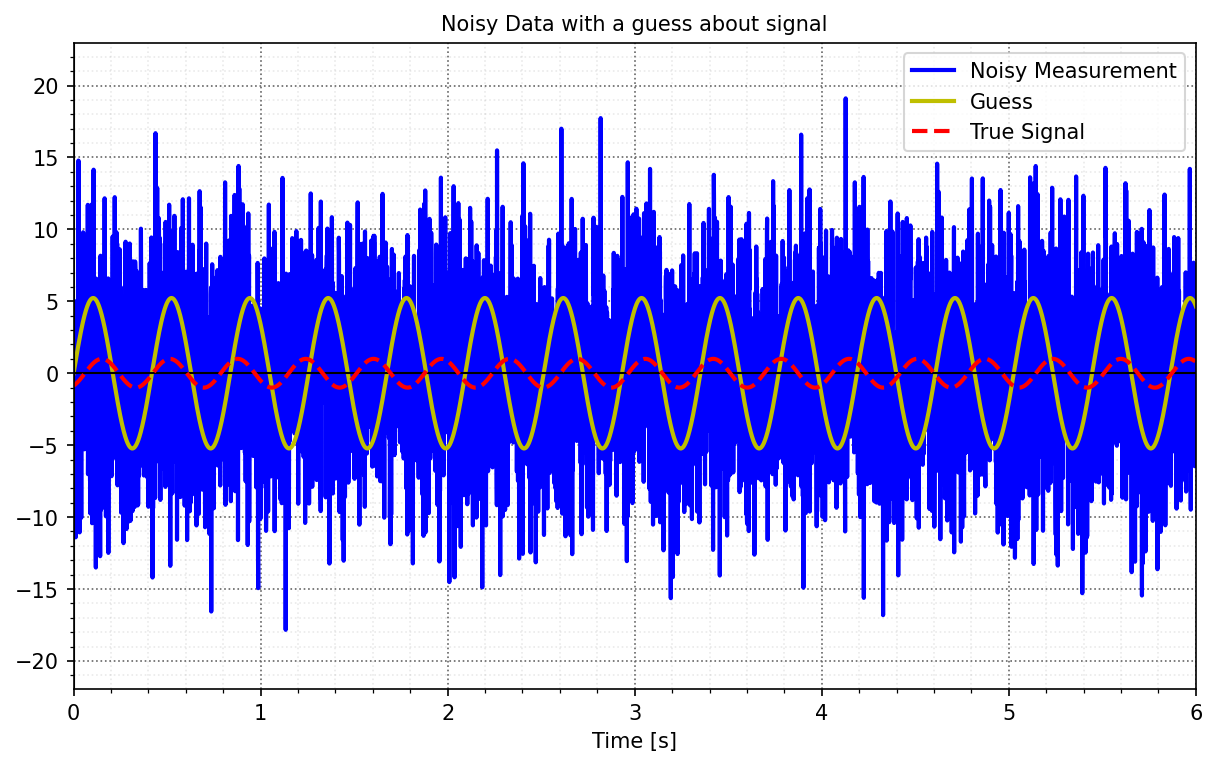

In [8]:
fig = plt.figure(figsize=(8, 5),dpi=150,constrained_layout = True)
plt.plot(t,y,'b-',label='Noisy Measurement')
plt.plot(t,y_guess,'y',label='Guess')
plt.xlim(0,tf/10)
plt.xlabel("Time [s]")
plt.title('Noisy Data with a guess about signal')
bm.nicegrid(ax=plt.gca())
plt.legend()
fig.savefig('./figs/Correlation1.pdf', dpi=600)
plt.plot(t,y_true,'r--',label='True Signal')
plt.legend()
fig.savefig('./figs/Correlation1t.pdf', dpi=600)
plt.show()


## Pattern Matching
* Even if we knew the frequency of the signal (orange line) - we don't known the phase offset ($\phi$)
* That offset depends on clock offsets in systems that are hard to keep synchronized in distributed systems (think satellites)

* Thus we have to do pattern matching - we basically create a replica signal as 
above, and then choose a range of $0\leq\phi\leq 2\pi$ to see if any match better than others

* Matching deptermined by computing the *correlation*
$$ C[j] =\sum_i y_{meas}[i] y_{replica}[i,j]$$
where $i$ is the index over mesurements taken and $j$ determines what value of $\phi$ is being used

* Must pay attention to the end points of the replica signal (use np.roll).

* We don't know the right amplitude to use either, but that is a scaling error in all $C[j]$ values - so can just look for the largest value across all computed.

In [9]:
# Assume we know the frequency of the signal, but not the phase. We can compute the correlation between our measured signal and a test signal with a guessed phase. The correlation will be maximized when the guessed phase matches the true phase.
y_guess = test_amplitude*np.sin(omega0 * t) 

In [10]:
# Must determine how data points we are going to sweep over phi
# nominally depends on frequency guess
N0 = int(T0/dt)  # samples per period
shift_index = np.arange(N0)
PHI = (omega0 * shift_index * dt) % (2*np.pi)

# Implement the correlation process between 2 signals 
# sweep overal all possible offsets in 1 loop
def my_correlate(A,B,N = N0):
    C = np.zeros([N,1]) # confirm which N is being used
    for ii in np.arange(0,N):
        C[ii] = np.correlate(A, np.roll(B,ii))
    return C

In [11]:
correlation_best = np.linalg.norm(y) * np.linalg.norm(test_amplitude*np.sin(omega0*t))
phi_grid = np.linspace(0, 2*np.pi, 500) 
# compute all correlations for the grid of phase offsets
corr_grid = np.array([np.correlate(y, test_amplitude*np.sin(omega0*t + pp))[0] / correlation_best for pp in phi_grid])

def func(phi_test=0):
    # manually sweep offset as phi_test
    y_test = test_amplitude*np.sin(omega0 * t + phi_test) 
    corr_test = np.correlate(y, y_test)[0] / correlation_best

    fig, axs = plt.subplots(1, 2,figsize=(12,5),dpi=150,constrained_layout=True)
    # Left: signal comparison
    axs[0].plot(t, y, 'b-', label='Meas')
    axs[0].plot(t, y_true, 'c-', label='Truth')
    axs[0].plot(t, y_test, 'r--', label='Guess')
    axs[0].set_xlim(0, 3)
    axs[0].set_xlabel('Time [s]')
    axs[0].set_title(f'$\\phi = {phi_test:.2f}$')
    axs[0].legend(loc=1)
    bm.nicegrid(axs[0])
    tt = axs[0].text(0.25, -np.max(y), f'Actual $\\phi = {phi_true:.2f}$')
    tt.set_bbox(dict(facecolor='green', alpha=0.25, edgecolor='green'))

    # Right: correlation over all phase
    axs[1].plot(phi_grid, corr_grid, 'k-', lw=2)
    axs[1].plot(phi_test, corr_test, 'ro', ms=8)
    axs[1].set_xlabel('$\\phi$')
    axs[1].set_ylabel('Normalized correlation')
    axs[1].set_title(f'Current correlation = {corr_test:.2f}')
    axs[1].set_xlim(0, 2*np.pi)
    axs[1].set_ylim(1.1*np.min(corr_grid), 1.1*np.max(corr_grid))
    bm.nicegrid(axs[1])

    plt.show()

yout = interactive(func, phi_test=(0, 2*np.pi, 0.05))
yout

interactive(children=(FloatSlider(value=0.0, description='phi_test', max=6.283185307179586, step=0.05), Output…

## Automate the manual process above - still assumes we know the frequency

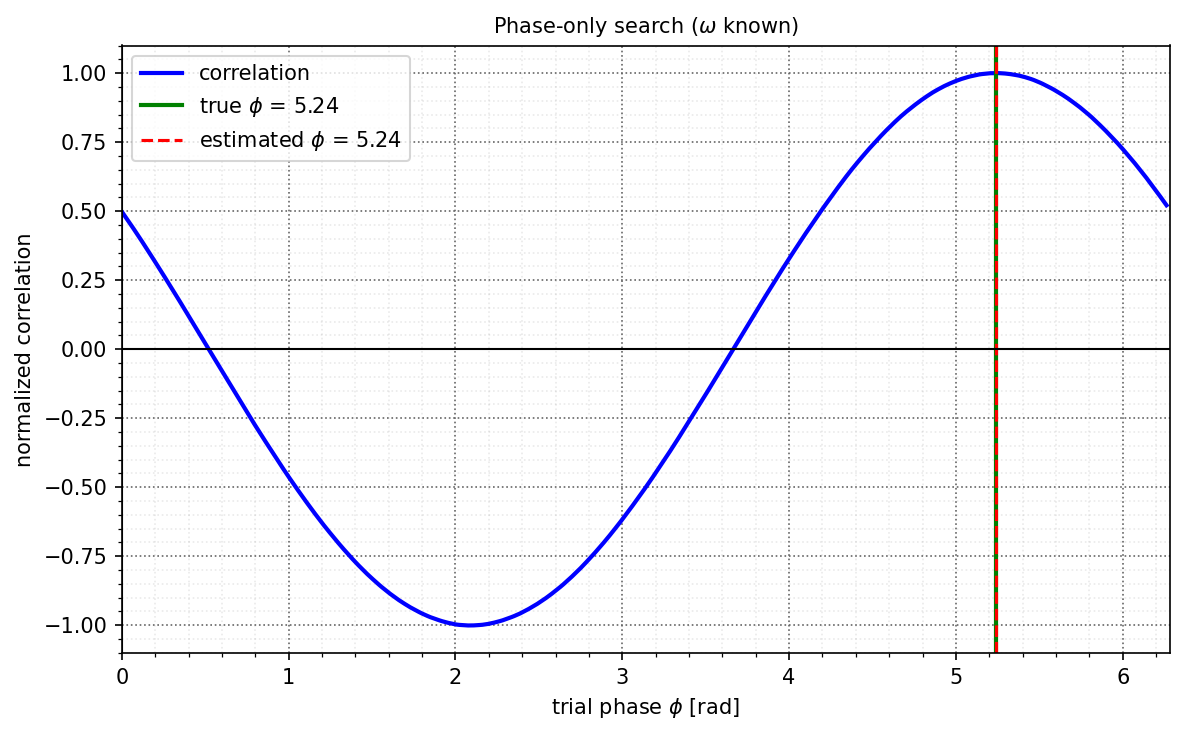

In [12]:
# Phase-only test: frequency known, sweep the phase
y_ref = test_amplitude*np.sin(omega0 * t)
correlation_guess = my_correlate(y_ref, y).ravel()
correlation_normalized = correlation_guess / correlation_guess.max()
phi_corr = PHI.ravel()[np.argmax(correlation_guess)].item()

fig = plt.figure(figsize=(8, 5))
plt.plot(PHI, correlation_normalized, 'b-', label='correlation')
plt.axvline(phi_true, color='g', lw=2,            label=rf'true $\phi$ = {phi_true:.2f}')
plt.axvline(phi_corr, color='r', ls='--', lw=1.5, label=rf'estimated $\phi$ = {phi_corr:.2f}')
plt.xlabel(r'trial phase $\phi$ [rad]'); plt.ylabel('normalized correlation')
plt.xlim(0, 2*np.pi)
plt.title(r'Phase-only search ($\omega$ known)')
plt.legend(); bm.nicegrid()
fig.savefig('./figs/Correlation2.pdf', dpi=600, bbox_inches='tight')
plt.show()

## Harder case - what if we don't know $\omega$ very well
* Why that might happen?

In [13]:
# Set up a range of possible Omega values 
# Recall truth is Omega0
# Create a range of Nw values of possible Omegas about the true Omega0
# Set up a range of possible Omega values
Nw = N0
omega_range = np.linspace(omega_lower_bound, omega_upper_bound, Nw)
ind = (np.abs(omega_range - omega0)).argmin()  # index of right answer

shift_index = np.arange(N0)

CC = np.zeros((len(omega_range), N0))
for ii, om in enumerate(omega_range):
    y_ref = np.sin(om * t)
    CC[ii, :] = my_correlate(y_ref, y, N0).ravel()

CC /= np.max(CC)

In [14]:
def set_sparse_yticks(omega_range, ind, Nw, step=50, min_sep=20, maxticks=8):
    """
    Set y-ticks for imshow with:
    - symmetric ticks around ind using ±step*k
    - inclusion of endpoints (0, Nw-1)
    - removal of ticks that are too close
    """

    # Generate symmetric indices
    k_min = -(ind // step)
    k_max = (Nw - 1 - ind) // step
    idxs = [ind + k * step for k in range(k_min, k_max + 1)]

    # Include endpoints and center
    idxs = sorted(set([0, ind, Nw - 1] + idxs))

    # Filter out ticks that are too close
    filtered = []
    for i in idxs:
        if not filtered or abs(i - filtered[-1]) >= min_sep:
            filtered.append(i)

    if len(filtered) > maxticks:
        stride = int(np.ceil(len(filtered) / maxticks))
        filtered = filtered[::stride]
        if ind not in filtered:
            # Find closest index in filtered to ind and replace it with ind
            closest_idx = min(range(len(filtered)), key=lambda i: abs(filtered[i] - ind))
            filtered[closest_idx] = ind
        filtered = sorted(filtered)

    # Create labels
    labels = [f"{omega_range[i]:.1f}" for i in filtered]

    # Apply
    plt.yticks(filtered, labels)

In [15]:
# Look for best correlation across all freq and phi sweeps
ind, N_phi_pred = np.unravel_index(np.argmax(CC), CC.shape)

omega_pred = omega_range[ind]
phi_pred = (omega_pred * N_phi_pred * dt) % (2*np.pi)

N_phi_true = int(np.round(phi_true / (omega0 * dt))) % N0 # index of right answer

In [16]:
print(f'\nTrue Omega {omega0:.1f} rad/s')
print(f'Pred Omega {omega_pred:.1f} rad/s\n')
print(f'True Phi {phi_true:.2f} rad')
print(f'Pred Phi {phi_pred:.2f} rad')


True Omega 17.3 rad/s
Pred Omega 17.3 rad/s

True Phi 5.24 rad
Pred Phi 5.43 rad


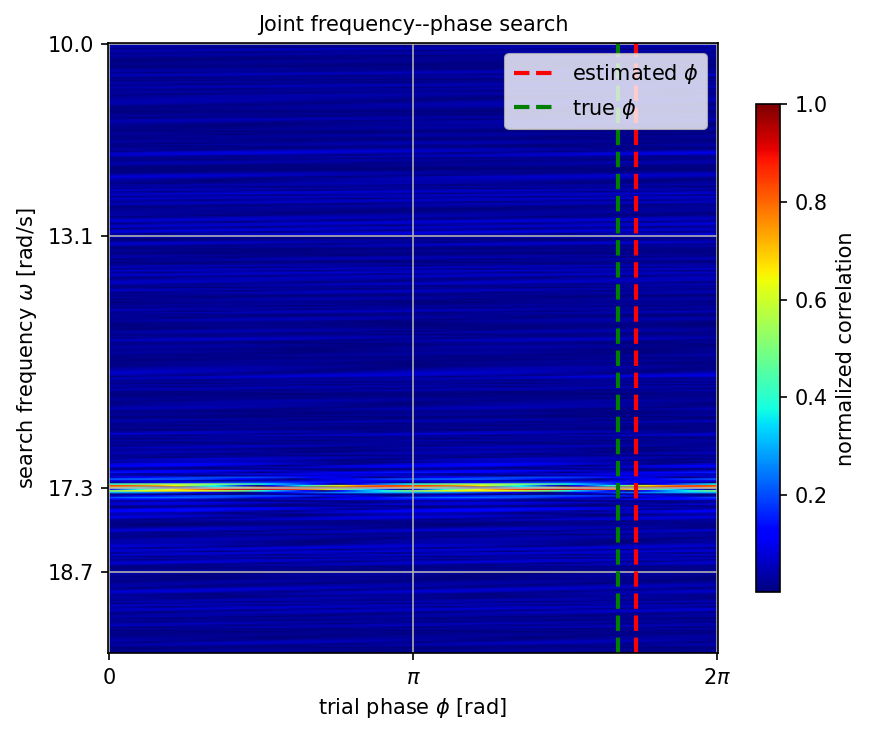

In [17]:
fig = plt.figure(figsize=(6, 5))
im = plt.imshow(np.abs(CC), cmap='jet', aspect='auto')
set_sparse_yticks(omega_range, ind, Nw, step=50, min_sep=20, maxticks=6)

plt.axvline(N_phi_pred, color='r', ls='--', label=r'estimated $\phi$')
plt.axvline(N_phi_true, color='g', ls='--', label=r'true $\phi$')

plt.xticks([0, N0//2, N0-1], ['0', r'$\pi$', r'$2\pi$'])
plt.xlabel(r'trial phase $\phi$ [rad]')
plt.ylabel(r'search frequency $\omega$ [rad/s]')
plt.title('Joint frequency--phase search')
plt.colorbar(im, shrink=0.8, label='normalized correlation')
plt.legend(loc='upper right')
fig.savefig('./figs/Correlation3.pdf', dpi=600, bbox_inches='tight')
plt.show()

## Alternate Approach

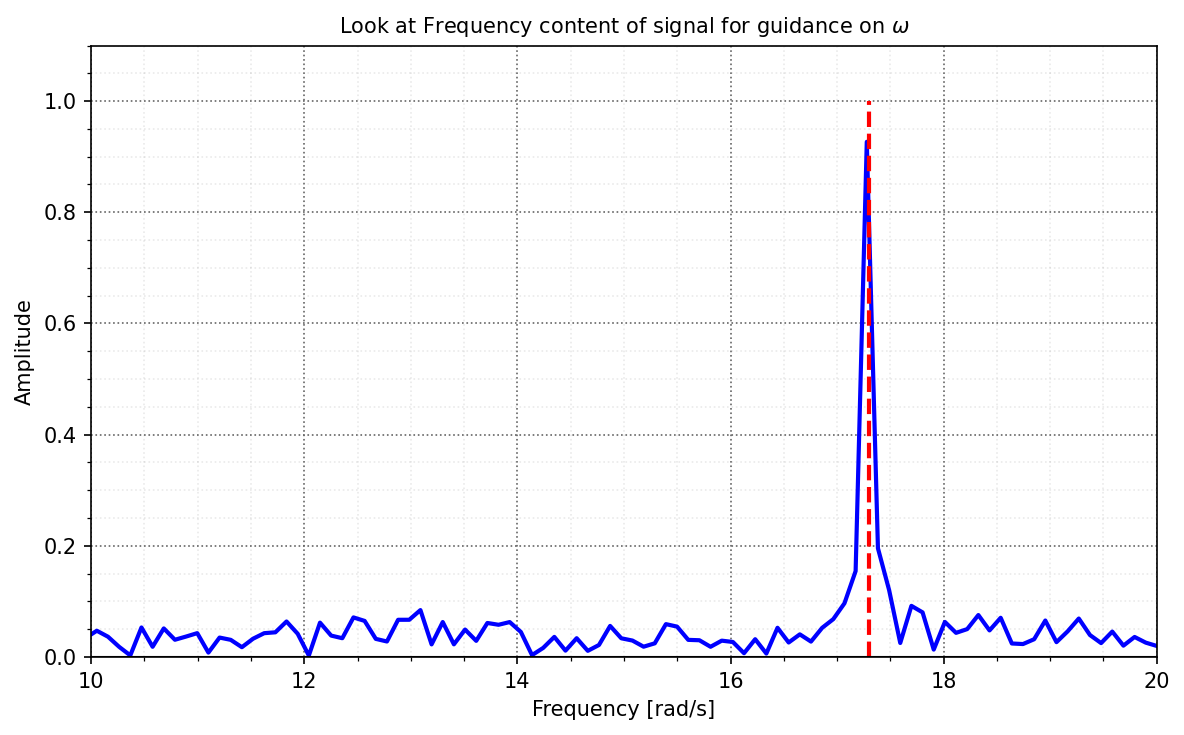

In [18]:
# Alternate way to estimate Omega given the measured data - look for the peak in the FFT plot
from scipy.fft import fft, fftfreq

# Number of samples in normalized_tone
Nfft = len(t)

fig = plt.figure(figsize=(8, 5))
yf = fft(y)
ff = fftfreq(Nfft, dt)[1:Nfft//2]*2*np.pi
plt.plot(ff, 2.0/Nfft * np.abs(yf[1:Nfft//2]),'b-')
plt.plot([omega0, omega0], [0,1],'r--')

plt.ylabel('Amplitude')
plt.xlabel('Frequency [rad/s]')
plt.xlim([omega_lower_bound, omega_upper_bound])
plt.ylim([0, 1.1])
plt.title("Look at Frequency content of signal for guidance on $\omega$")
bm.nicegrid()
plt.show()

## GPS Example

In [19]:
def gps_ca_code(prn, N=1023):
    """GPS C/A Gold code (length 1023) returned as a +/-1 sequence."""
    # J. B.-Y. Tsui, Fundamentals of Global Positioning System Receivers: A Software Approach, 2nd ed., Wiley, 2005 (Ch. 5). (Also Borre et al., A Software-Defined GPS and Galileo Receiver, Birkhäuser, 2007.)
    g2_taps = {1:(2,6),2:(3,7),3:(4,8),4:(5,9),5:(1,9),6:(2,10),7:(1,8),
               8:(2,9),9:(3,10),10:(2,3),11:(3,4),12:(5,6),13:(6,7),14:(7,8),
               15:(8,9),16:(9,10),17:(1,4),18:(2,5),19:(3,6),20:(4,7),
               21:(5,8),22:(6,9),23:(1,3),24:(4,6),25:(5,7),26:(6,8),
               27:(7,9),28:(8,10),29:(1,6),30:(2,7),31:(3,8),32:(4,9)}
    s1, s2 = g2_taps[prn]
    g1 = np.ones(10, int); g2 = np.ones(10, int)
    code = np.empty(N, int)
    for i in range(N):
        code[i] = g1[9] ^ (g2[s1-1] ^ g2[s2-1])
        fb1 = g1[2] ^ g1[9]                                   # G1 taps 3,10
        fb2 = g2[1] ^ g2[2] ^ g2[5] ^ g2[7] ^ g2[8] ^ g2[9]   # G2 taps 2,3,6,8,9,10
        g1 = np.roll(g1, 1); g1[0] = fb1
        g2 = np.roll(g2, 1); g2[0] = fb2
    return 1 - 2*code                                         # {0,1} -> {+1,-1}

def circ_xcorr(a, b, normalize=True):
    """Circular cross-correlation via FFT; normalized to [-1,1], lag 0 centered."""
    r = np.fft.ifft(np.fft.fft(a) * np.conj(np.fft.fft(b))).real
    if normalize:
        r = r / np.sqrt(np.sum(a*a) * np.sum(b*b))
    return np.fft.fftshift(r)

rng = np.random.default_rng(0)
A_sig, sigma = 1.0, 4.0                        # per-sample SNR = A^2/sigma^2 = -20 dB
true_lag = 200
present_prn, other_prn = 11, 2
code1 = gps_ca_code(present_prn)   # the satellite actually in 'received'
code2 = gps_ca_code(other_prn)     # a different satellite, for the CDMA contrast

N = code1.size
lags = np.round(np.fft.fftshift(np.fft.fftfreq(N)) * N).astype(int)
print(f"Two C/A Gold codes, length {N}, values {set(np.unique(code1))}")


Two C/A Gold codes, length 1023, values {1, -1}


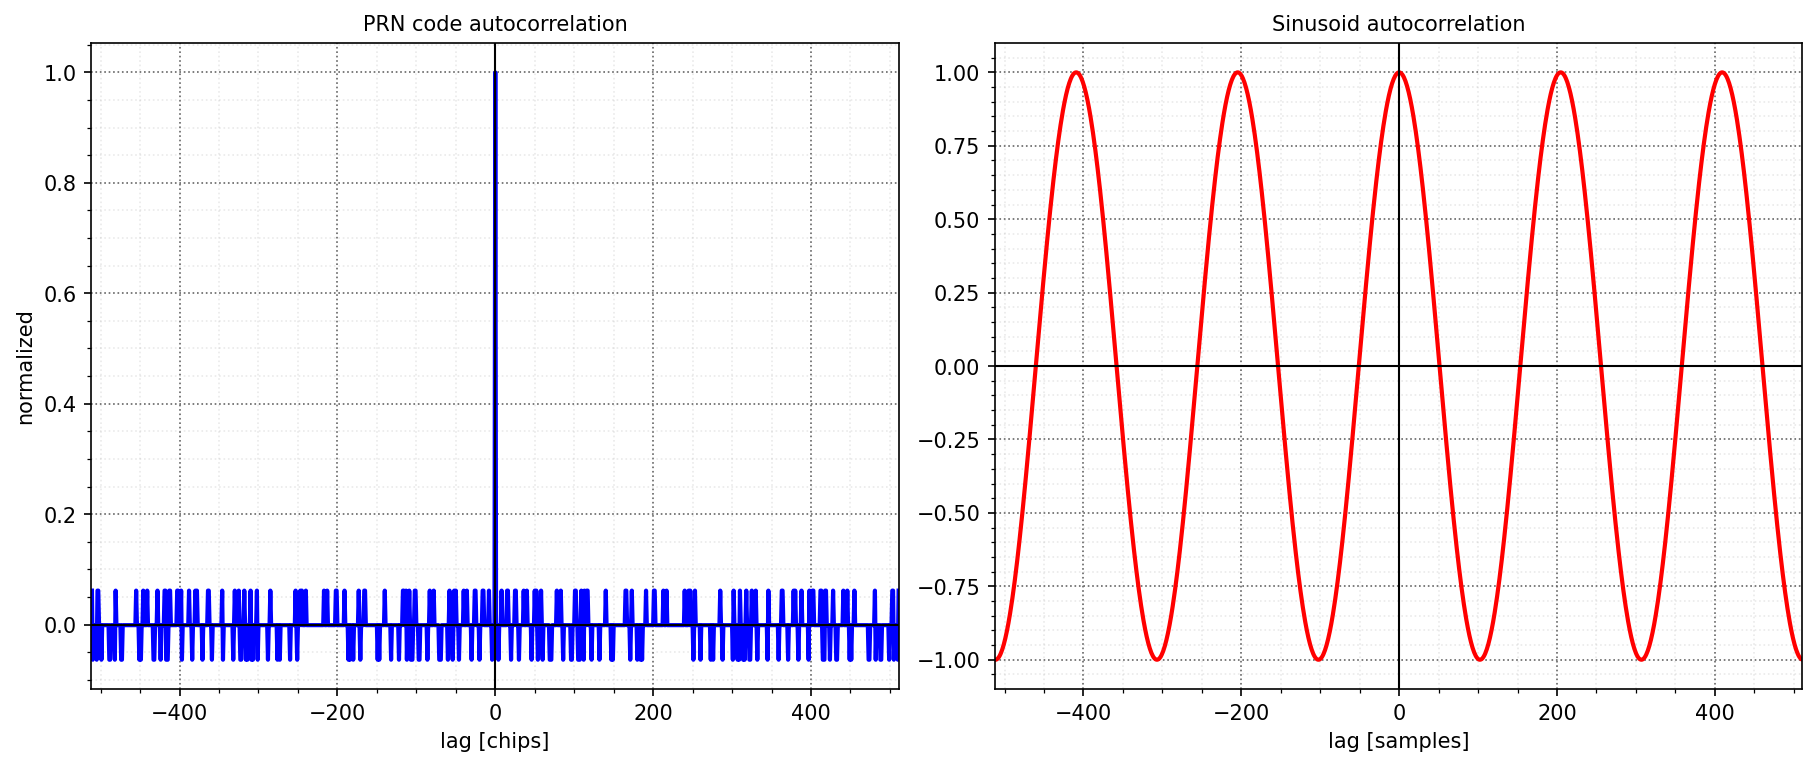

In [20]:
Rxx_code = circ_xcorr(code1, code1)
tone = np.sin(2*np.pi*5*np.arange(N)/N)        # 5 cycles across the window
Rxx_tone = circ_xcorr(tone, tone)

fig, ax = plt.subplots(1, 2, figsize=(12,5), constrained_layout=True)
ax[0].plot(lags, Rxx_code, 'b-', lw=2)
ax[0].set_title('PRN code autocorrelation'); ax[0].set_xlabel('lag [chips]')
ax[0].set_ylabel('normalized')
ax[1].plot(lags, Rxx_tone, 'r-', lw=2)
ax[1].set_title('Sinusoid autocorrelation'); ax[1].set_xlabel('lag [samples]')
for a in ax: a.set_xlim(-N//2, N//2); bm.nicegrid(a)
fig.savefig('./figs/Correlation_autocorr.pdf', bbox_inches='tight',dpi=600)
plt.show(); 


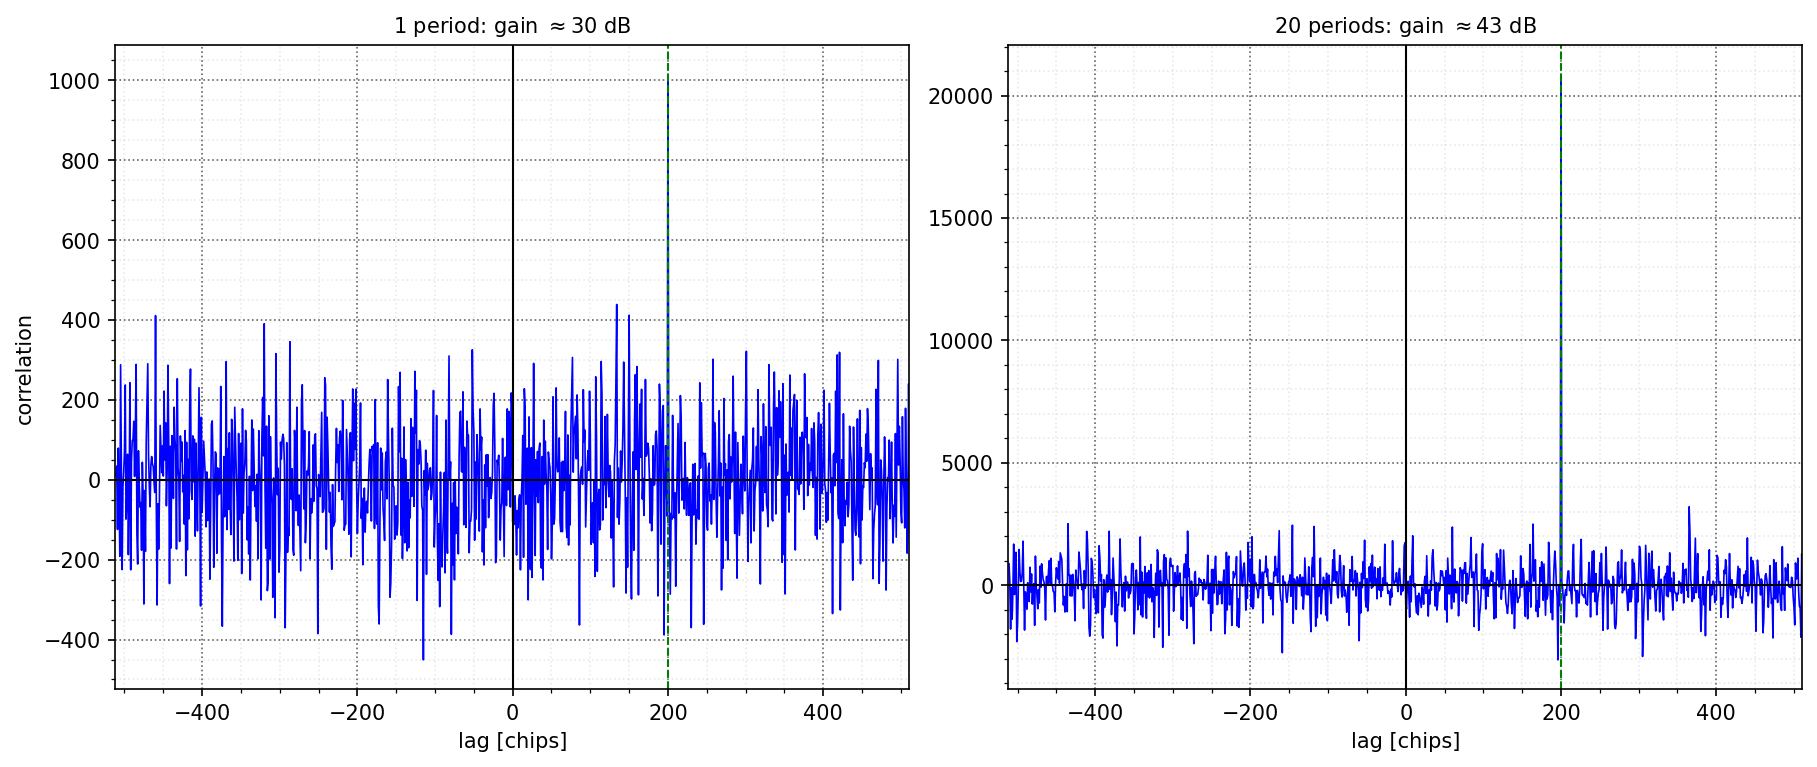

In [21]:
received = A_sig*np.roll(code1,true_lag) + sigma*rng.standard_normal(N)
corr_raw = circ_xcorr(received, code1, normalize=False)   # raw sum -> peak ~ N
snr_in, gain = 10*np.log10(A_sig**2/sigma**2), 10*np.log10(N)

Rxy = circ_xcorr(received, code1)       

def detect(M):
    # M periods of the delayed code, each in fresh noise (~M ms of signal)
    rx = np.tile(A_sig*np.roll(code1, true_lag), M) + sigma*rng.standard_normal(M*N)
    folded = rx.reshape(M, N).sum(axis=0)             # coherent integration over M periods
    return circ_xcorr(folded, code1, normalize=False)

fig, ax = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for a, M in zip(ax, (1, 20)):
    c = detect(M)
    a.plot(lags, c, 'b-', lw=0.8)
    a.axvline(true_lag, color='g', ls='--', lw=1)
    a.set_title(f'{M} period{"s" if M>1 else ""}: gain $\\approx${10*np.log10(M*N):.0f} dB')
    a.set_xlabel('lag [chips]'); a.set_xlim(-N//2, N//2); bm.nicegrid(a)
ax[0].set_ylabel('correlation')
plt.show(); 
fig.savefig('./figs/Correlation_Mdetection.pdf', bbox_inches='tight',dpi=600)


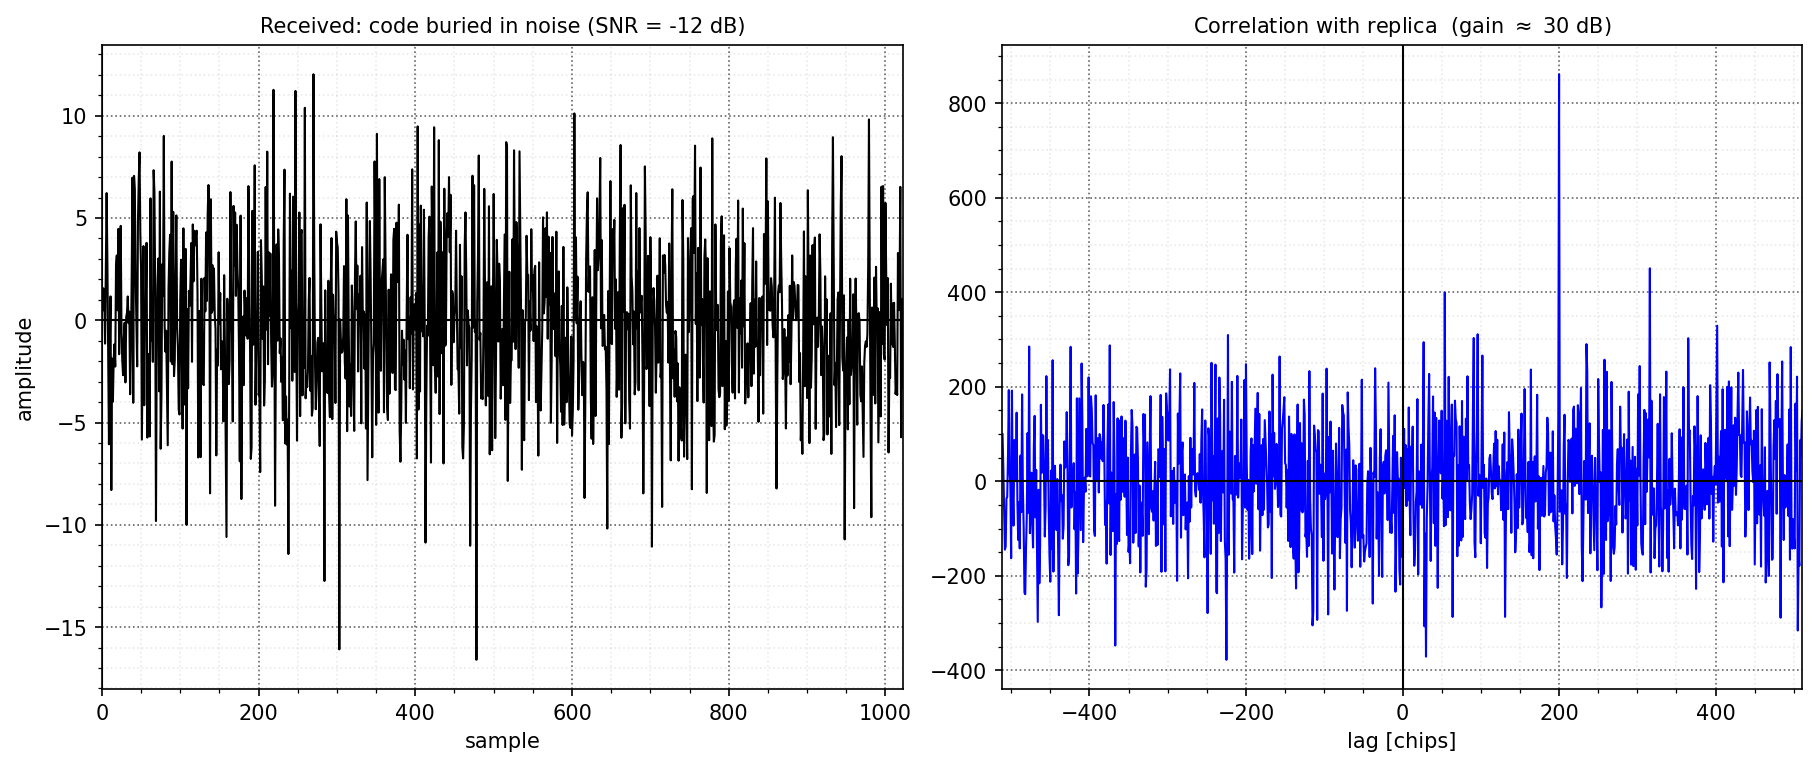

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(12,5), constrained_layout=True)
ax[0].plot(received, 'k-', lw=1)
ax[0].set_title(f'Received: code buried in noise (SNR = {snr_in:.0f} dB)')
ax[0].set_xlabel('sample'); ax[0].set_ylabel('amplitude')
ax[1].plot(lags, corr_raw, 'b-', lw=1)
ax[1].set_title(f'Correlation with replica  (gain $\\approx$ {gain:.0f} dB)')
ax[1].set_xlabel('lag [chips]'); ax[1].set_xlim(-N//2, N//2)
for a in ax: bm.nicegrid(a)
fig.savefig('./figs/Correlation_detection.pdf', bbox_inches='tight',dpi=600)
plt.show() 


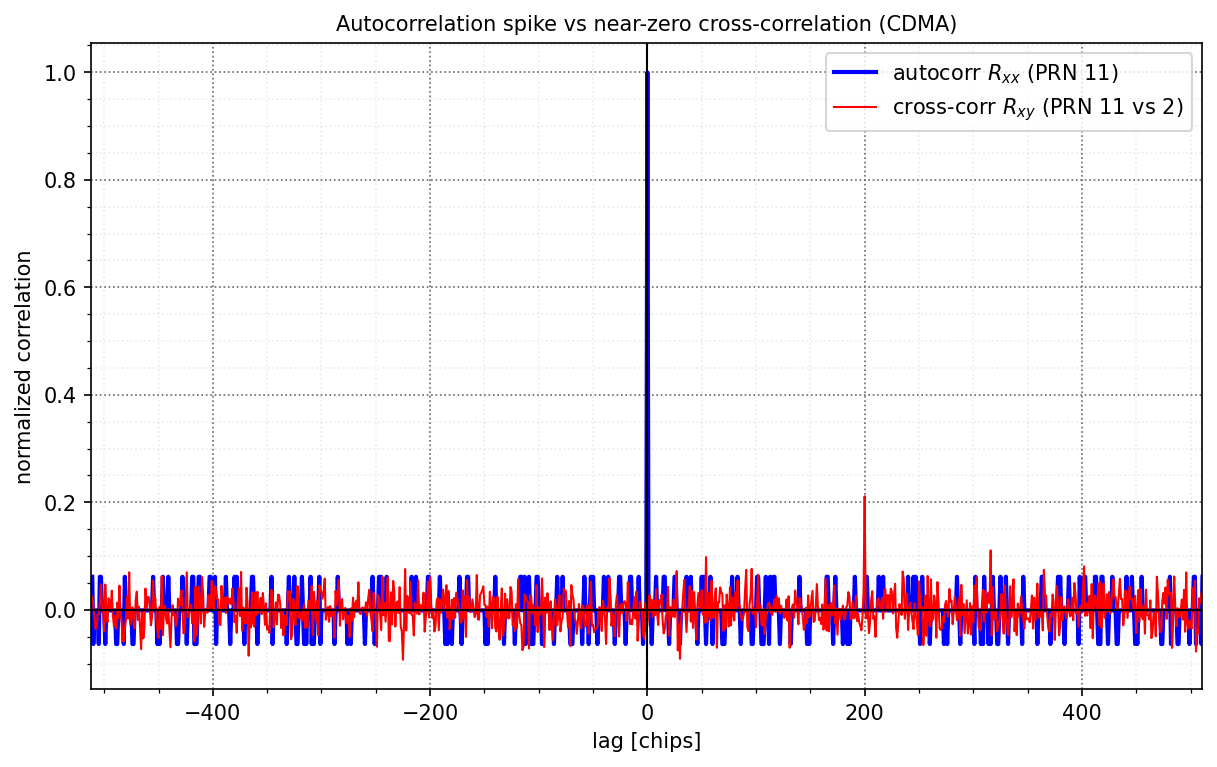

max |cross-corr| = 0.211   (autocorr peak = 1.0)


In [23]:
Rxx_code = circ_xcorr(code1, code1)
Rx1x2 = circ_xcorr(code1, code2)
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
ax.plot(lags, Rxx_code, 'b-', lw=2, label=f'autocorr $R_{{xx}}$ (PRN {present_prn})')
ax.plot(lags, Rxy,      'r-', lw=1, label=f'cross-corr $R_{{xy}}$ (PRN {present_prn} vs {other_prn})')

ax.set_xlim(-N//2, N//2); ax.set_xlabel('lag [chips]')
ax.set_ylabel('normalized correlation')
ax.set_title('Autocorrelation spike vs near-zero cross-correlation (CDMA)')
ax.legend() 
bm.nicegrid(ax)
fig.savefig('./figs/Correlation_crosscorr.pdf', bbox_inches='tight',dpi=600)
plt.show()
print(f"max |cross-corr| = {np.max(np.abs(Rxy)):.3f}   (autocorr peak = 1.0)")


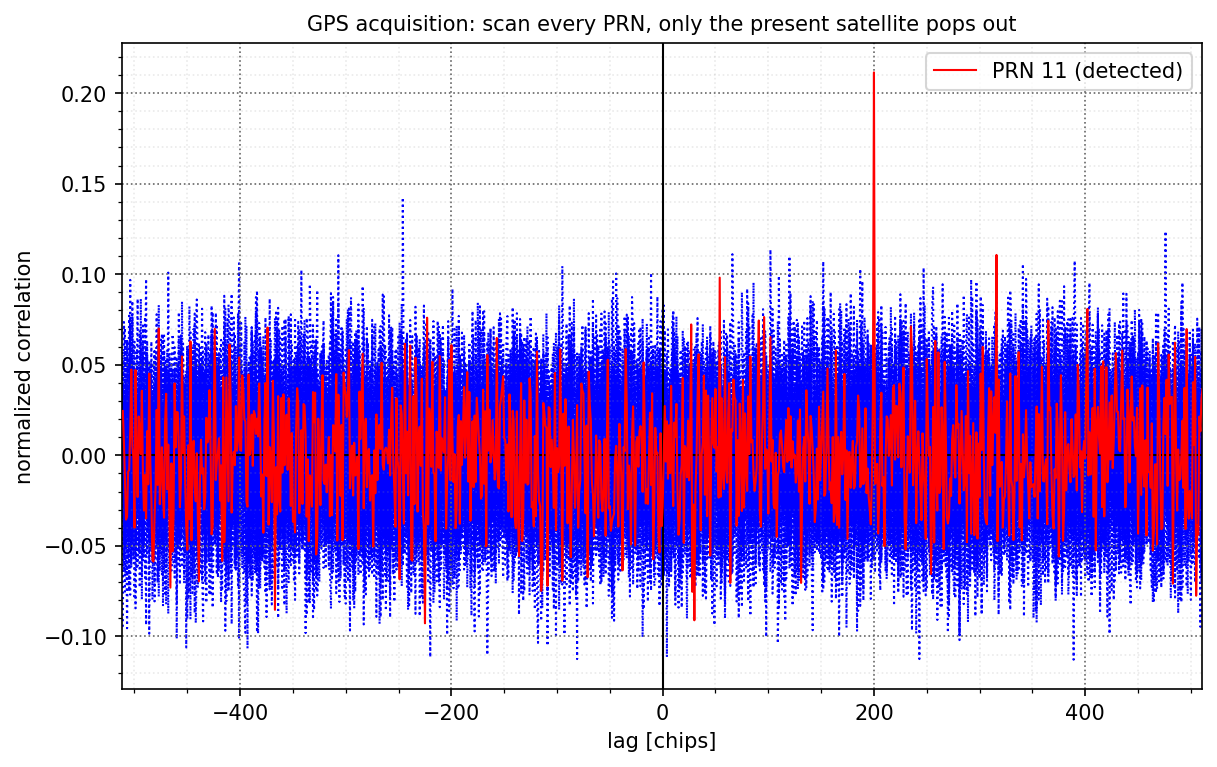

detected PRN 11 at lag 200 (peak 0.21); all others below threshold


In [24]:
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

best = (None, 0.0, None)                      # (prn, peak, lag)
for kk in range(1, 32):
    Rxy = circ_xcorr(received, gps_ca_code(kk))
    peak = np.max(np.abs(Rxy))
    hit = peak > 0.15
    ax.plot(lags, Rxy, 'r-' if hit else 'b:', lw=1, zorder=10 if hit else 1,
            label=f'PRN {kk} (detected)' if hit else None)
    if peak > best[1]:
        best = (kk, peak, lags[np.argmax(np.abs(Rxy))])

ax.set_xlim(-N//2, N//2); ax.set_xlabel('lag [chips]'); ax.set_ylabel('normalized correlation')
ax.set_title('GPS acquisition: scan every PRN, only the present satellite pops out')
ax.legend(); bm.nicegrid(ax)
fig.savefig('./figs/Correlation_acquire2.pdf', bbox_inches='tight',dpi=600)
plt.show() 
print(f"detected PRN {best[0]} at lag {best[2]} (peak {best[1]:.2f}); all others below threshold")


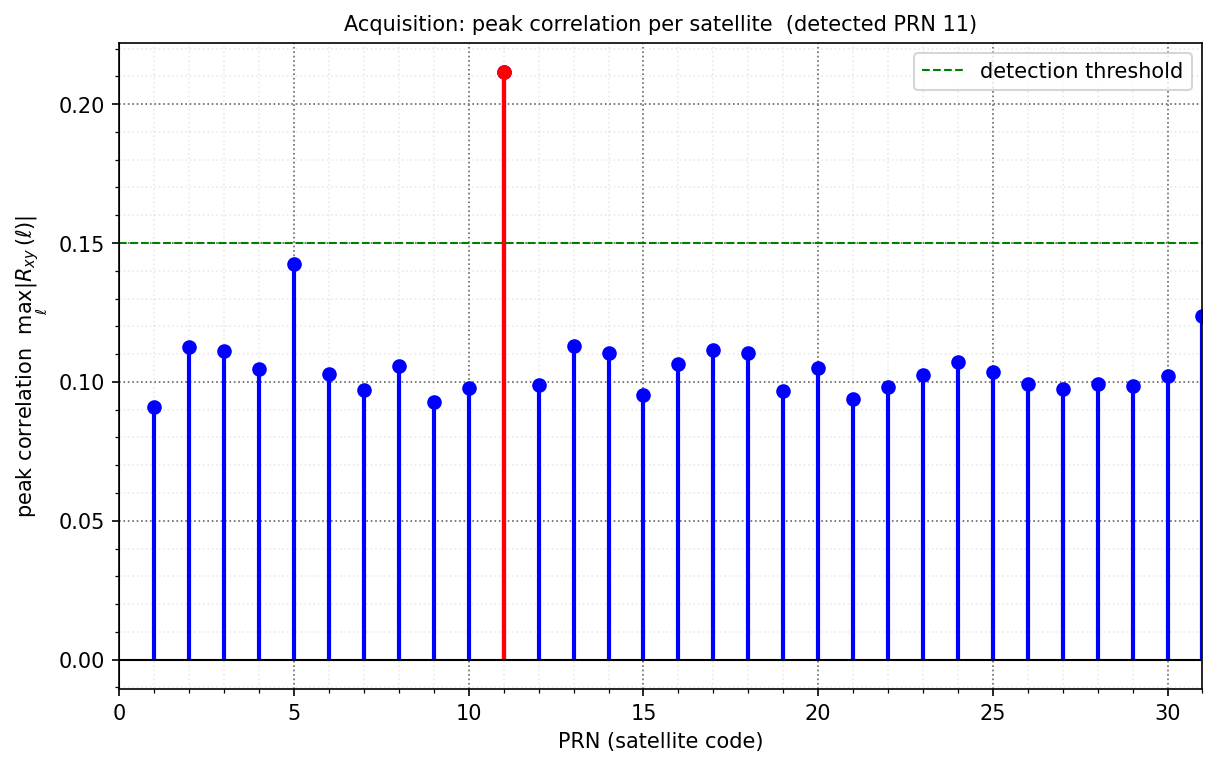

detected PRN 11: peak 0.21;  runner-up 0.14


In [25]:
prns  = np.arange(1, 32)
peaks = np.array([np.max(np.abs(circ_xcorr(received, gps_ca_code(p)))) for p in prns])
det   = int(prns[np.argmax(peaks)])

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
ax.stem(prns, peaks, linefmt='b-', markerfmt='bo', basefmt=' ')
ax.stem([det], [peaks[det-1]], linefmt='r-', markerfmt='ro', basefmt=' ')   # winner
ax.axhline(0.15, color='g', ls='--', lw=1, label='detection threshold')
ax.set_xlabel('PRN (satellite code)')
ax.set_ylabel(r'peak correlation  $\max_\ell |R_{xy}(\ell)|$')
ax.set_title(f'Acquisition: peak correlation per satellite  (detected PRN {det})')
ax.legend(); bm.nicegrid(ax)
fig.savefig('./figs/Correlation_acquire.pdf', bbox_inches='tight')
plt.show(); 
print(f"detected PRN {det}: peak {peaks[det-1]:.2f};  runner-up {np.sort(peaks)[-2]:.2f}")


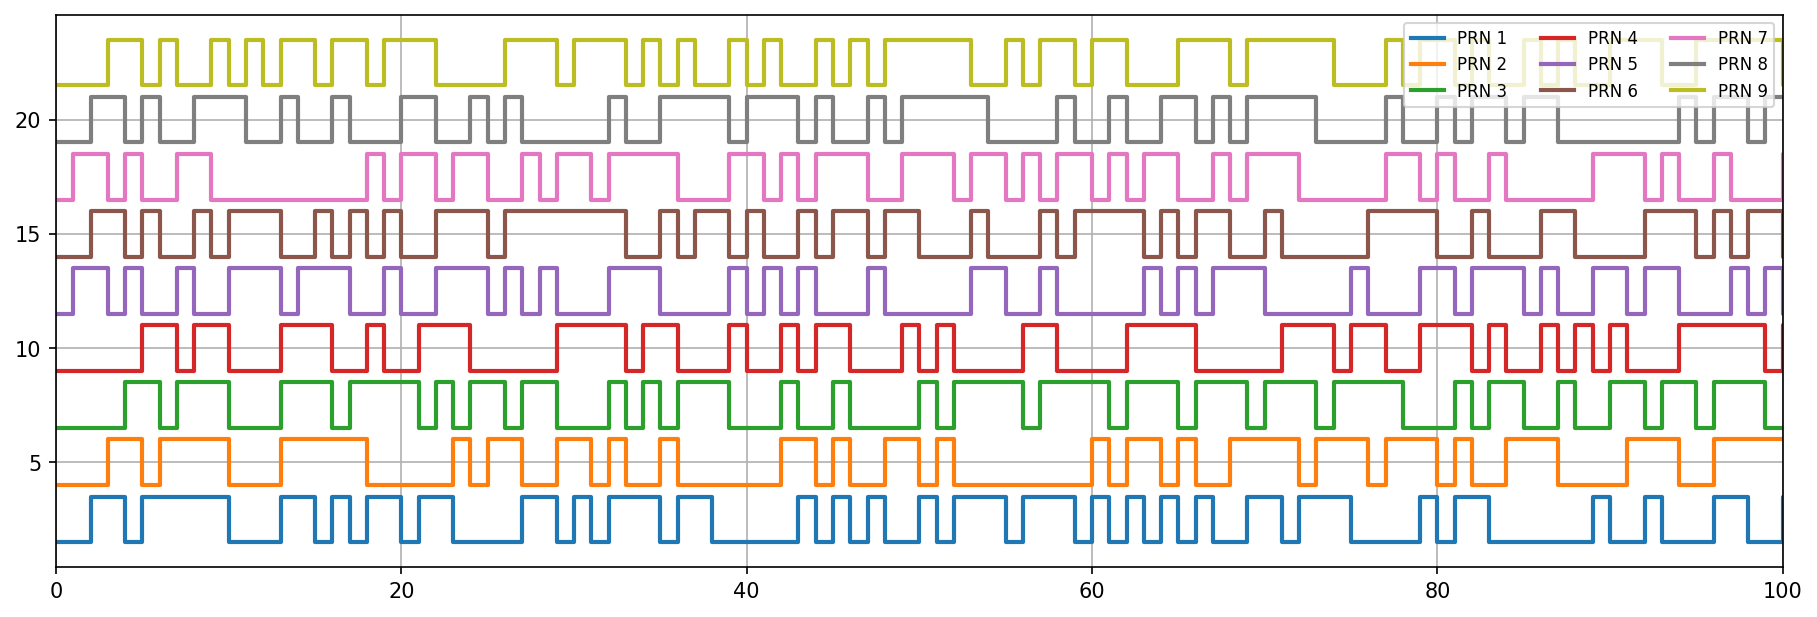

In [26]:
fig, ax = plt.subplots(figsize=(12, 4), constrained_layout=True)
n = np.arange(N)
for kk in range(1, 10):
    ax.step(n, 2.5*kk + gps_ca_code(kk), where='post', label=f'PRN {kk}')
ax.set_xlim(0, 100)
ax.legend(loc='upper right', ncol=3, fontsize=8)
fig.savefig('./figs/Correlation_codes.pdf', bbox_inches='tight', dpi=600)
plt.show()
